In [ ]:
import numpy as np
import pandas as pd
# To run this file you need to install the dependencies in requirements.txt using
#   pip install -r requirements.txt
# in some python environment (either base or one you created)

In [ ]:
prices_r0dneg1 = pd.read_csv("data/prices_round_0_day_-1.csv", sep=";")
prices_r0dneg2 = pd.read_csv("data/prices_round_0_day_-2.csv", sep=";")
trades_r0dneg1 = pd.read_csv("data/trades_round_0_day_-1.csv", sep=";")
trades_r0dneg2 = pd.read_csv("data/trades_round_0_day_-2.csv", sep=";")

prices_r0dneg1["timestamp"] += 1_000_000
trades_r0dneg1["timestamp"] += 1_000_000
prices = pd.concat([prices_r0dneg2, prices_r0dneg1], ignore_index=True)
trades = pd.concat([trades_r0dneg2, trades_r0dneg1], ignore_index=True)

In [41]:
groups_prices = prices.groupby("product")
ems_prices = groups_prices.get_group("EMERALDS")
tomas_prices = groups_prices.get_group("TOMATOES")
ems_prices.iloc[1_000_000//100 -2: 1_000_000//100+5]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
19996,-2,999800,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0,0.0
19999,-2,999900,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
20001,-1,1000000,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
20002,-1,1000100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
20004,-1,1000200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
20007,-1,1000300,EMERALDS,9992,11,9990,29,NaN,NaN,10008,11,10010,29,NaN,NaN,10000.0,0.0
20009,-1,1000400,EMERALDS,9992,12,9990,25,NaN,NaN,10008,12,10010,25,NaN,NaN,10000.0,0.0


In [42]:
trades.drop(["buyer", "seller", "currency"], axis=1, inplace=True)
groups_trades = trades.groupby("symbol")
ems_trades = groups_trades.get_group("EMERALDS")
tomas_trades = groups_trades.get_group("TOMATOES")
ems_trades.head()

,timestamp,symbol,price,quantity
2,4000,EMERALDS,10008.0,7
4,5200,EMERALDS,9992.0,5
7,10500,EMERALDS,10008.0,5
9,11300,EMERALDS,9992.0,3
16,22800,EMERALDS,10000.0,6


In [43]:
import matplotlib.pyplot as plt

def plot_prices(prices):
    plt.close('all')  # Close all existing figures
    fig, ax = plt.subplots(figsize=(14, 6))  # Create new figure and axis explicitly

    #ax.plot(prices.timestamp, prices["bid_price_1"], label="Bid", alpha=0.7, marker="o", markersize=3)
    #ax.plot(prices.timestamp, prices["ask_price_1"], label="Ask", alpha=0.7, marker="s", markersize=3)
    ax.plot(prices.timestamp, prices["mid_price"], label="Mid", linewidth=2.5, color="red", alpha=0.9)

    ax.set_xlabel("Timestamp", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.legend(fontsize=11)
    ax.set_title("Bid, Mid, Ask", fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

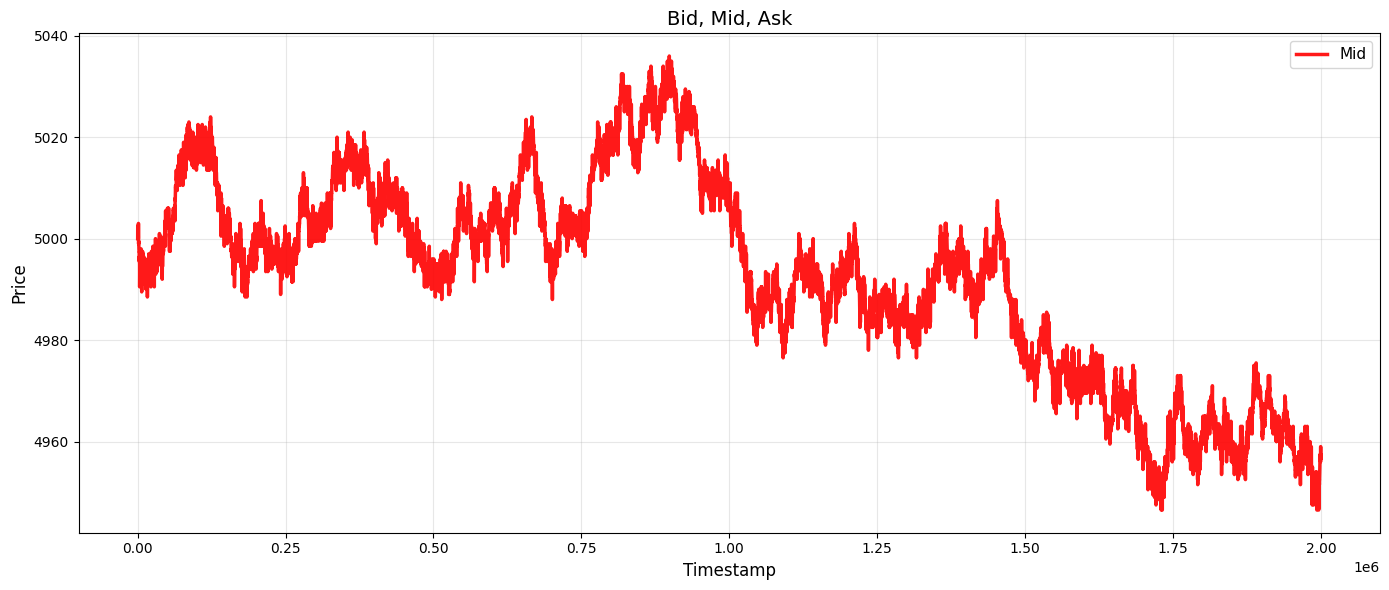

In [44]:
plot_prices(tomas_prices)
#tomas_prices

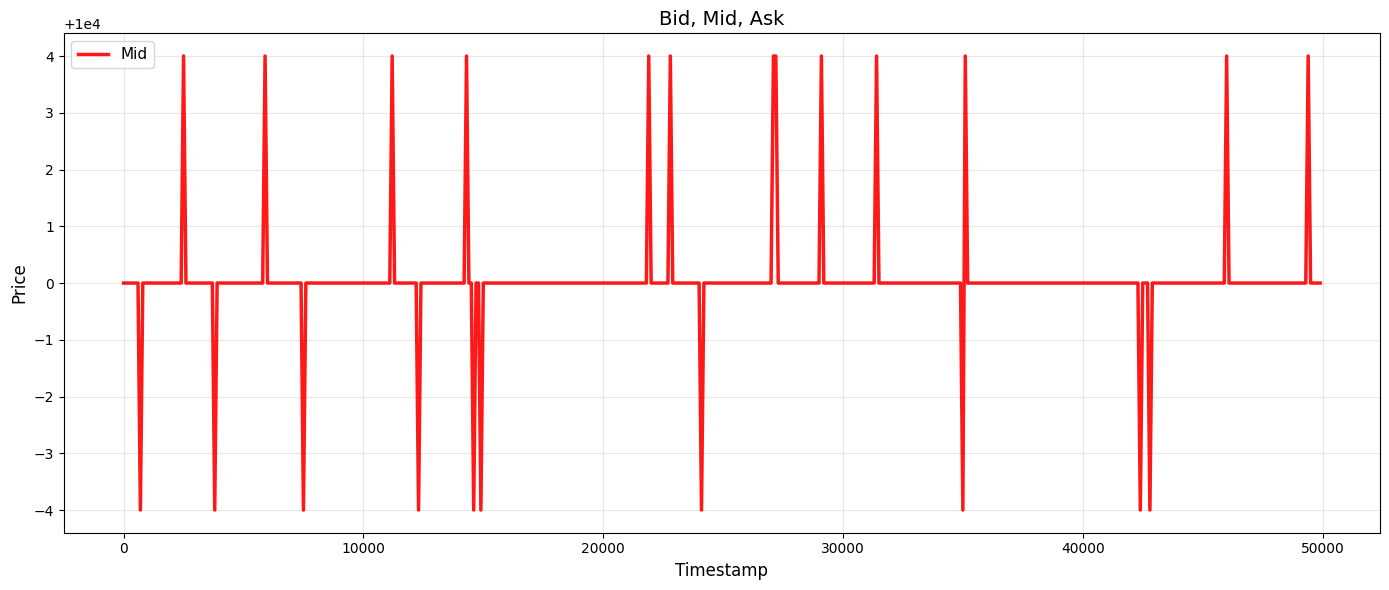

In [45]:
plot_prices(ems_prices[:500])
#ems_prices["mid_price"].describe()

In [46]:
def plot_trades(trades):
    plt.close('all')  # Close all existing figures
    fig, ax = plt.subplots(figsize=(14, 6))  # Create new figure and axis explicitly

    # Scale quantities to reasonable circle sizes (between 20 and 300)
    quantity_min = trades["quantity"].min()
    quantity_max = trades["quantity"].max()
    scaled_sizes = 20 + (trades["quantity"] - quantity_min) / (quantity_max - quantity_min) * 280

    # Plot trades as circles with size proportional to quantity
    # Use higher transparency and smaller edge widths for better visibility with dense data
    ax.scatter(trades.timestamp, trades["price"], s=scaled_sizes, label="Trades (size ∝ quantity)", 
               color="red", alpha=0.4, edgecolors='darkred', linewidth=0.3)

    ax.set_xlabel("Timestamp", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.legend(fontsize=11)
    ax.set_title("Trades (circle size proportional to quantity)", fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

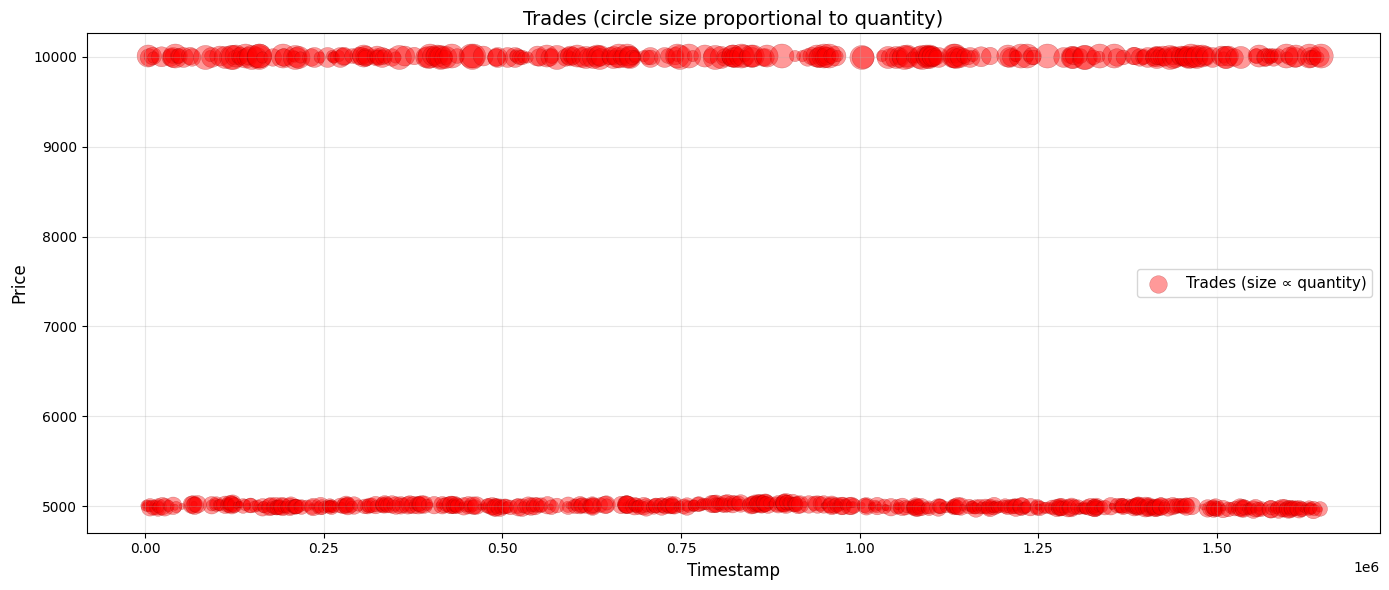

In [47]:
plot_trades(trades[:1_000])
#trades.quantity.describe()

In [48]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import ruptures as rpt

def run_time_series_suite(series, change_point=False):
    """
    Runs a comprehensive battery of tests on a pandas Series.
    Note that the change-point analysis is optional and can be computationally intensive for large series.
    The function returns a dictionary with results from
        1. stationarity tests
        2. autocorrelation tests, and
        3. optionally change-point detection
    along with summary statistics for research purposes.
    """
    results = {}
    
    # 1. Stationarity Tests
    # ADF: Null hypothesis is that the series is non-stationary (has a unit root)
    print("Running ADF test...")
    adf_test = adfuller(series.dropna())
    results['ADF (Stationarity)'] = {'p-value': adf_test[1], 'Stationary': adf_test[1] < 0.05}
    
    # KPSS: Null hypothesis is that the series is stationary
    print("Running KPSS test...")
    kpss_test = kpss(series.dropna(), regression='c', nlags="auto")
    results['KPSS (Trend Stationary)'] = {'p-value': kpss_test[1], 'Stationary': kpss_test[1] > 0.05}
    
    # 2. Autocorrelation Tests
    # Ljung-Box: Null hypothesis is that the data is independently distributed (white noise)
    print("Running Ljung-Box test...")
    lb_test = acorr_ljungbox(series.dropna(), lags=[10], return_df=True)
    results['Ljung-Box (White Noise)'] = {'p-value': lb_test['lb_pvalue'].values[0], 'Is White Noise': lb_test['lb_pvalue'].values[0] > 0.05}
    
    # 3. Change-point Analysis (Using Pelt algorithm)
    # Detects sudden shifts in mean or variance
    if change_point:
        print("Running Change-point Analysis...")
        algo = rpt.Pelt(model="rbf").fit(series.values)
        change_points = algo.predict(pen=10)
        results['Change Points Detected'] = len(change_points) - 1 # Exclude the last index
    
    # 4. Summary Statistics for Research
    print("Done!")
    results['Descriptive'] = {
        'Mean': series.mean(),
        'Std Dev': series.std(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt()
    }
    
    return results

# Example Usage:
# df = pd.read_csv('your_data.csv', index_col='date', parse_dates=True)
# analysis = run_time_series_suite(df['your_column'])

In [49]:
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
import scipy.stats as stats

def run_advanced_series_suite(series):
    results = {}
    clean_series = series.dropna()

    # 1. Hurst Exponent (Martingale vs Mean Reversion)
    # Returns: Hurst factor, simplifies the "nature" of the walk
    H, c, data = compute_Hc(clean_series, kind='price', simplified=True)
    results['Hurst Exponent'] = {
        'Value': H,
        'Interpretation': 'Mean-Reverting' if H < 0.45 else 'Trending' if H > 0.55 else 'Martingale/Random Walk'
    }

    # 2. Variance Ratio Test (Statistical check for Martingale)
    # Null Hypothesis: The series is a Random Walk
    vr = VarianceRatio(clean_series)
    results['Variance Ratio (Martingale)'] = {
        'p-value': vr.pvalue,
        'Is Random Walk': vr.pvalue > 0.05
    }

    # 3. Volatility & Fat Tails
    # Kurtosis > 3 means "Fat Tails" (Extreme events are more likely than normal)
    kurt = stats.kurtosis(clean_series)
    results['Volatility Profile'] = {
        'Excess Kurtosis': kurt,
        'Has Fat Tails': kurt > 1, 
        'Std Dev': clean_series.std()
    }

    return results

In [50]:
run_time_series_suite(ems_prices["mid_price"])

Running ADF test...
Running KPSS test...
Running Ljung-Box test...


/var/folders/v2/8kmltg8j0d1glmqdfvfvmprc0000gn/T/ipykernel_16726/3861528981.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags="auto")


Done!


{'ADF (Stationarity)': {'p-value': 0.0, 'Stationary': True},
 'KPSS (Trend Stationary)': {'p-value': np.float64(0.1),
  'Stationary': np.True_},
 'Ljung-Box (White Noise)': {'p-value': np.float64(0.41998294294141925),
  'Is White Noise': np.True_},
 'Descriptive': {'Mean': np.float64(9999.9976),
  'Std Dev': np.float64(0.7233397549008702),
  'Skewness': np.float64(-0.09152254767584751),
  'Kurtosis': np.float64(27.587628858410444)}}